# Shipment Delivery Analysis
**Evan William | Tugas Day 16, folder pengumpulan Day 17**

Tujuan: mengukur keterlambatan pengiriman, membandingkan kurir, dan membuat
prediksi dasar serta rekomendasi operasional dari dataset simulasi.

Dataset asli dari [tautan tugas](https://drive.google.com/file/d/1YS9AzFdYqvrhcDBcEezSLyisCpNTKvXC/view).
CSV disertakan agar analisis dapat diulang tanpa akses Drive. Dataset bukan
data operasional Anteraja nyata; nama kurir adalah label dalam simulasi.

**Colab:** unggah notebook ini dan `shipments.csv` ke sesi yang sama,
lalu pilih Runtime > Run all. Sel berikut menyediakan pilihan upload
jika CSV belum tersedia. Output notebook ini sudah dijalankan secara lokal;
bukan screenshot atau klaim eksekusi dari akun Colab.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import numpy as np
import pandas as pd
from IPython.display import display

SEED = 42
DATA_PATH = Path("shipments.csv")
OUTPUT = Path("results")
OUTPUT.mkdir(exist_ok=True)
required_columns = ["tracking_number", "courier", "weight_kg", "distance_km",
                    "promised_hours", "actual_hours"]
numeric_columns = ["weight_kg", "distance_km", "promised_hours", "actual_hours"]

if not DATA_PATH.exists():
    try:
        from google.colab import files
    except ImportError as error:
        raise FileNotFoundError("Letakkan shipments.csv di folder notebook.") from error
    print("Unggah shipments.csv asli dari tugas.")
    files.upload()
assert DATA_PATH.exists(), "File harus bernama shipments.csv."
raw = pd.read_csv(DATA_PATH)
assert set(required_columns).issubset(raw.columns), "Kolom wajib belum lengkap."
print("Python:", platform.python_version())
print("SHA-256 dataset:", hashlib.sha256(DATA_PATH.read_bytes()).hexdigest())
print("Ukuran awal (baris, kolom):", raw.shape)
display(raw.head())

Python: 3.12.10
SHA-256 dataset: 0592817a2a2138fdd8e7905e20fff9c9809c87a88871f8d9b2b9b5537128ab17
Ukuran awal (baris, kolom): (220, 7)


,tracking_number,courier,weight_kg,distance_km,promised_hours,actual_hours,delay_hours
0,ANT0140,Sari,2.3,50.4,19,26.3,7.3
1,ANT0066,Andi,2.8,14.9,10,13.1,3.1
2,ANT0096,Budi,3.0,26.0,12,17.2,5.2
3,ANT0023,Dedi,3.1,13.6,9,10.3,1.3
4,ANT0064,Andi,2.0,11.5,9,10.8,1.8


## 1. Fundamental Python: variabel, list, dictionary, kondisi, loop
List menyimpan nama kolom, dictionary menyimpan satu pengiriman,
dan loop membaca beberapa baris. `if` menentukan apakah kiriman terlambat.
Ini demonstrasi konsep, bukan pengganti analisis seluruh dataset.

In [2]:
example_shipments = raw[required_columns].head(3).to_dict("records")
for shipment in example_shipments:
    difference = shipment["actual_hours"] - shipment["promised_hours"]
    label = "terlambat" if difference > 0 else "tepat waktu / lebih cepat"
    print(f"{shipment['tracking_number']} | {shipment['courier']} | {label}")

ANT0140 | Sari | terlambat
ANT0066 | Andi | terlambat
ANT0096 | Budi | terlambat


## 2. Audit data sebelum cleaning
Periksa ukuran, tipe, nilai kosong, duplikat penuh, dan resi berulang.
Tidak menambahkan data kotor palsu ke dataset analisis. Jika data sumber
sudah bersih, jumlah baris yang dihapus boleh nol.

In [3]:
raw.info()
print("Nilai kosong per kolom:")
display(raw.isna().sum().rename("missing").to_frame())
print("Duplikat penuh:", int(raw.duplicated().sum()))
print("Resi berulang:", int(raw["tracking_number"].duplicated().sum()))
display(raw[numeric_columns].describe())

<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tracking_number  220 non-null    str    
 1   courier          220 non-null    str    
 2   weight_kg        220 non-null    float64
 3   distance_km      220 non-null    float64
 4   promised_hours   220 non-null    int64  
 5   actual_hours     220 non-null    float64
 6   delay_hours      220 non-null    float64
dtypes: float64(4), int64(1), str(2)
memory usage: 12.2 KB
Nilai kosong per kolom:


,missing
tracking_number,0
courier,0
weight_kg,0
distance_km,0
promised_hours,0
actual_hours,0
delay_hours,0


Duplikat penuh: 0
Resi berulang: 0


,weight_kg,distance_km,promised_hours,actual_hours
count,220.000000,220.000000,220.000000,220.000000
mean,3.270455,21.928182,11.486364,15.631364
std,1.487325,16.067197,4.015358,7.224892
min,0.700000,2.300000,7.000000,7.000000
25%,2.200000,10.075000,8.750000,10.000000
50%,3.100000,16.800000,10.000000,13.300000
75%,3.900000,29.550000,13.000000,19.475000
max,10.100000,64.200000,22.000000,40.100000


## 3. Cleaning dan validasi
Pilih kolom wajib, rapikan teks, ubah numerik dengan `to_numeric`,
ubah infinity menjadi kosong, gunakan `dropna`, lalu `drop_duplicates`.
Tolak nilai yang tidak masuk akal (berat <= 0, jarak < 0, janji <= 0,
atau durasi aktual < 0). Resi sama dengan informasi berbeda perlu
ditinjau, bukan dipilih sembarangan.

Kolom delay bawaan sumber tidak dipercaya begitu saja: dihitung ulang
sebagai `max(actual_hours - promised_hours, 0)`. Paket yang lebih cepat
tidak memiliki keterlambatan negatif.

In [4]:
def clean_shipments(frame):
    df = frame[required_columns].copy()
    audit = {"rows_before": len(df), "original_columns": len(frame.columns)}
    for column in ["tracking_number", "courier"]:
        df[column] = df[column].astype("string").str.strip().replace("", pd.NA)
    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")
    df[numeric_columns] = df[numeric_columns].replace([np.inf, -np.inf], np.nan)
    before = len(df)
    df = df.dropna(subset=required_columns)
    audit["removed_missing_or_unparseable"] = before - len(df)
    before = len(df)
    df = df.drop_duplicates()
    audit["removed_duplicates"] = before - len(df)
    valid = ((df["weight_kg"] > 0) & (df["distance_km"] >= 0)
             & (df["promised_hours"] > 0) & (df["actual_hours"] >= 0))
    audit["removed_invalid_ranges"] = int((~valid).sum())
    df = df.loc[valid].reset_index(drop=True)
    if df["tracking_number"].duplicated().any():
        raise ValueError("Resi duplikat dengan isi berbeda perlu ditinjau.")
    df["delay_hours"] = (df["actual_hours"] - df["promised_hours"]).clip(lower=0)
    audit["rows_after"] = len(df)
    assert not df.empty, "Tidak ada data valid untuk dianalisis."
    assert not df.isna().any().any()
    assert not df.duplicated().any()
    assert df["tracking_number"].is_unique
    assert np.isfinite(df[numeric_columns + ["delay_hours"]].to_numpy()).all()
    assert (df["delay_hours"] >= 0).all()
    return df, audit

clean, cleaning_audit = clean_shipments(raw)
display(pd.Series(cleaning_audit, name="hasil cleaning").to_frame())
print("Validasi: tidak ada kosong, duplikat, infinity, atau delay negatif.")
display(clean.head())

,hasil cleaning
rows_before,220
original_columns,7
removed_missing_or_unparseable,0
removed_duplicates,0
removed_invalid_ranges,0
rows_after,220


Validasi: tidak ada kosong, duplikat, infinity, atau delay negatif.


,tracking_number,courier,weight_kg,distance_km,promised_hours,actual_hours,delay_hours
0,ANT0140,Sari,2.3,50.4,19,26.3,7.3
1,ANT0066,Andi,2.8,14.9,10,13.1,3.1
2,ANT0096,Budi,3.0,26.0,12,17.2,5.2
3,ANT0023,Dedi,3.1,13.6,9,10.3,1.3
4,ANT0064,Andi,2.0,11.5,9,10.8,1.8


## 4. Statistik NumPy
Minimum = delay terkecil; median = nilai tengah; mean = rata-rata.
Standar deviasi menunjukkan sebaran delay. Gunakan `ddof=1` untuk standar
deviasi sampel; versi populasi `ddof=0` disajikan agar definisinya jelas.

In [5]:
delay = clean["delay_hours"].to_numpy(dtype=float)
statistics = {
    "min_hours": float(np.min(delay)),
    "median_hours": float(np.median(delay)),
    "mean_hours": float(np.mean(delay)),
    "std_sample_hours": float(np.std(delay, ddof=1)) if len(delay) > 1 else None,
    "std_population_hours": float(np.std(delay, ddof=0)),
}
display(pd.Series(statistics, name="jam").to_frame().round(4))
print("Seluruh angka memakai delay yang dihitung ulang, bukan kolom delay sumber.")

,jam
min_hours,0.0000
median_hours,3.0500
mean_hours,4.1450
std_sample_hours,3.8070
std_population_hours,3.7984


Seluruh angka memakai delay yang dihitung ulang, bukan kolom delay sumber.


### Uji cleaning terpisah
Contoh kecil di bawah sengaja berisi nilai rusak untuk membuktikan fungsi
cleaning bekerja. Contoh ini TIDAK digabungkan dengan dataset analisis.

In [6]:
test_frame = pd.DataFrame([
    ["TEST-1", " Kurir A ", "1.5", "5", "10", "8"],
    ["TEST-1", " Kurir A ", "1.5", "5", "10", "8"],
    ["TEST-2", "Kurir B", "rusak", "7", "10", "12"],
    ["TEST-3", "", "2", "7", "10", "12"],
    ["TEST-4", "Kurir B", "-2", "7", "10", "12"],
    ["TEST-5", "Kurir B", "2", "inf", "10", "12"],
], columns=required_columns)
checked, test_audit = clean_shipments(test_frame)
assert len(checked) == 1 and checked.iloc[0]["delay_hours"] == 0
assert checked.iloc[0]["courier"] == "Kurir A"
assert test_audit["removed_duplicates"] == 1
print("PASS: numerik teks, duplikat, kosong, range negatif, infinity, dan clipping.")

PASS: numerik teks, duplikat, kosong, range negatif, infinity, dan clipping.


## 5. Loop manual dibanding groupby
Loop membuat dictionary total dan jumlah per kurir, kemudian menghitung
rata-rata. `groupby` melakukan pengelompokan yang sama dengan kode lebih
singkat. Hasil dibandingkan dengan toleransi pembulatan floating point.

In [7]:
totals, counts = {}, {}
for shipment in clean.to_dict("records"):
    name = shipment["courier"]
    totals[name] = totals.get(name, 0.0) + shipment["delay_hours"]
    counts[name] = counts.get(name, 0) + 1
manual_means = pd.Series({name: totals[name] / counts[name] for name in totals})
grouped_means = clean.groupby("courier")["delay_hours"].mean()
np.testing.assert_allclose(manual_means.sort_index(), grouped_means.sort_index())
courier_summary = clean.groupby("courier").agg(
    shipment_count=("tracking_number", "count"),
    mean_delay_hours=("delay_hours", "mean"),
    median_delay_hours=("delay_hours", "median"),
).sort_values("mean_delay_hours", ascending=False)
highest = courier_summary["mean_delay_hours"].max()
worst_couriers = courier_summary.index[np.isclose(courier_summary["mean_delay_hours"], highest)].tolist()
display(pd.DataFrame({"loop_mean": manual_means, "groupby_mean": grouped_means}).round(4))
display(courier_summary.round(4))
print("PASS: loop manual dan groupby menghasilkan rata-rata yang sama.")
print("Rata-rata keterlambatan tertinggi:", ", ".join(worst_couriers), f"({highest:.2f} jam).")

,loop_mean,groupby_mean
Andi,2.1000,2.1000
Budi,3.4000,3.4000
Citra,7.9023,7.9023
Dedi,1.6024,1.6024
Sari,5.8000,5.8000


,shipment_count,mean_delay_hours,median_delay_hours
courier,,,
Citra,43,7.9023,7.50
Sari,44,5.8000,5.75
Budi,45,3.4000,2.90
Andi,46,2.1000,1.75
Dedi,42,1.6024,1.15


PASS: loop manual dan groupby menghasilkan rata-rata yang sama.
Rata-rata keterlambatan tertinggi: Citra (7.90 jam).


## 6. Visualisasi Matplotlib
Batang diurutkan dari rata-rata delay tertinggi. Warna gelap menyorot
kelompok tertinggi; label angka dan nama tetap menyampaikan informasi
tanpa bergantung pada warna. Rata-rata tidak membuktikan kurir adalah
penyebab: komposisi jarak, berat, dan outlier bisa berbeda per kurir.

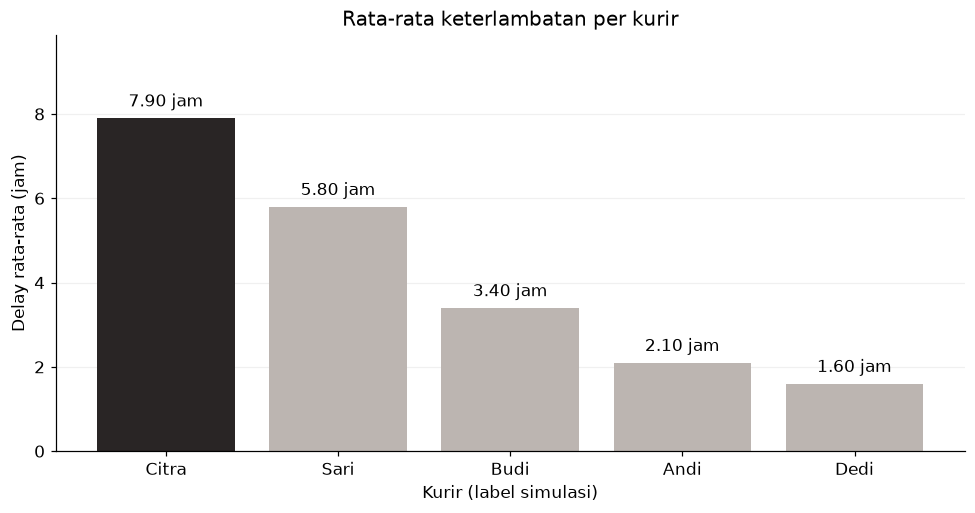

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False})
fig, ax = plt.subplots(figsize=(9, 4.8))
values = courier_summary["mean_delay_hours"]
bars = ax.bar(values.index, values.values,
              color=["#292525" if name in worst_couriers else "#bcb5b1" for name in values.index])
ax.bar_label(bars, labels=[f"{v:.2f} jam" for v in values], padding=5)
ax.set(title="Rata-rata keterlambatan per kurir", xlabel="Kurir (label simulasi)", ylabel="Delay rata-rata (jam)")
ax.set_ylim(0, float(values.max()) * 1.25)
ax.grid(axis="y", alpha=0.18)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(OUTPUT / "courier-delay.png", dpi=170)
plt.show()

## 7. Korelasi jarak dan berat terhadap delay
Pearson r berada antara -1 dan +1: mendekati +1 berarti hubungan linear
positif lebih kuat, mendekati nol berarti hubungan linear lemah.
Korelasi bukan bukti sebab-akibat. Jika kolom konstan, korelasi tidak
terdefinisi; hasil itu tidak boleh diganti menjadi angka rekaan.

In [9]:
correlation_matrix = clean[["distance_km", "weight_kg", "delay_hours"]].corr(method="pearson")
correlations = correlation_matrix.loc[["distance_km", "weight_kg"], "delay_hours"]
display(correlation_matrix.round(4))
for feature, value in correlations.items():
    print(f"{feature} vs delay_hours: r={value:.4f}" if pd.notna(value) else f"{feature}: korelasi tidak terdefinisi")
defined = correlations.dropna()
if not defined.empty:
    print("Hubungan linear terkuat secara absolut:", defined.abs().idxmax())

,distance_km,weight_kg,delay_hours
distance_km,1.0000,0.2033,0.7101
weight_kg,0.2033,1.0000,0.2198
delay_hours,0.7101,0.2198,1.0000


distance_km vs delay_hours: r=0.7101
weight_kg vs delay_hours: r=0.2198
Hubungan linear terkuat secara absolut: distance_km
